<a href="https://colab.research.google.com/github/elonsobrevilla06-byte/SpamEmailLogisticRegression/blob/main/SpamEmailUsingLogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
pip install kagglehub scikit-learn pandas numpy

In [15]:
import pandas as pd
import numpy as np
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt


In [16]:
path = kagglehub.dataset_download('jackksoncsie/spam-email-dataset')
data = pd.read_csv(f"{path}/emails.csv")

data.head()

Using Colab cache for faster access to the 'spam-email-dataset' dataset.


,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [17]:
data.isna().any(axis =None)

np.False_

In [18]:
data.columns

Index(['text', 'spam'], dtype='object')

<Axes: ylabel='count'>

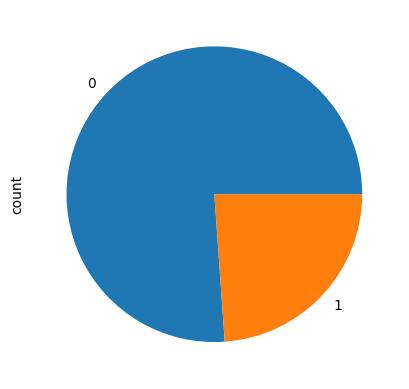

In [19]:
data.spam.value_counts().plot(kind = 'pie')

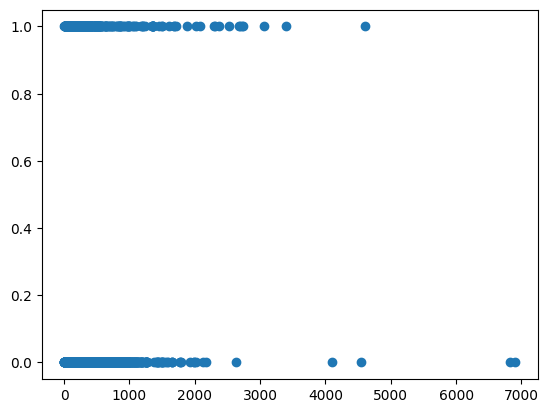

In [20]:
vectorizer  = CountVectorizer()
X = vectorizer.fit_transform(data.text)
y = data.spam


total_word = np.array(X.sum(axis = 1))
plt.scatter(total_word, y)
plt.show()



In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2 ,random_state  = 1)

In [22]:
model = LogisticRegression(max_iter = 100)
model.fit(X_train, y_train)
prediction = model.predict(X_test)

print(prediction)

[0 0 0 ... 0 0 1]


In [23]:
#Evaluation
print("Accruacy", accuracy_score(y_test, prediction))


Accruacy 0.9912739965095986


<Axes: ylabel='count'>

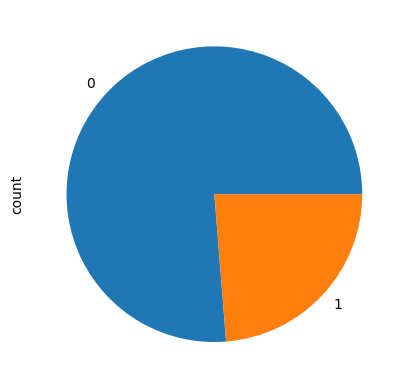

In [28]:
pd.Series(prediction).value_counts().plot(kind = 'pie')

In [24]:
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       876
           1       0.98      0.99      0.98       270

    accuracy                           0.99      1146
   macro avg       0.99      0.99      0.99      1146
weighted avg       0.99      0.99      0.99      1146



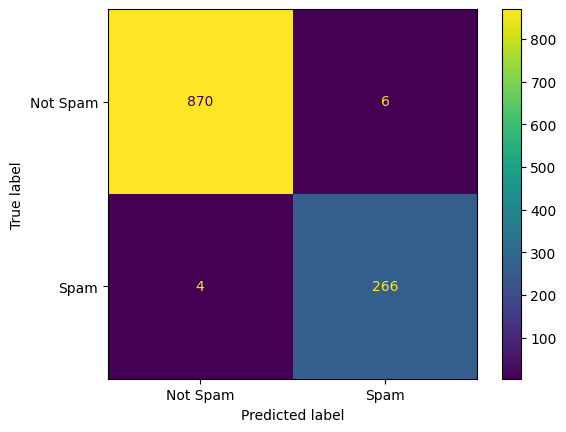

In [32]:
cm = confusion_matrix(y_test, prediction)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["Not Spam", "Spam"])
cm_display.plot()
plt.show()